In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [ ]:
from datetime import datetime
from collections import Counter
from scipy import stats


In [ ]:
! pip install catboost

In [ ]:
from sklearn.preprocessing       import RobustScaler
from sklearn.model_selection     import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.decomposition       import PCA, TruncatedSVD
from sklearn.manifold            import TSNE
from sklearn.linear_model        import LogisticRegression
from sklearn.neighbors           import KNeighborsClassifier
from sklearn.tree                import DecisionTreeClassifier
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics             import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix,
    precision_recall_curve, roc_curve, classification_report
)

from imblearn.under_sampling     import RandomUnderSampler
from imblearn.over_sampling      import SMOTE

from xgboost                     import XGBClassifier
from lightgbm                    import LGBMClassifier
from catboost                    import CatBoostClassifier

import joblib

warnings.filterwarnings("ignore")

In [ ]:
train_transaction = pd.read_csv("/content/train_transaction.csv")
train_identity    = pd.read_csv("/content/train_identity.csv")
test_transaction  = pd.read_csv("/content/test_transaction.csv")
test_identity     = pd.read_csv("/content/test_identity.csv")

In [ ]:
# MERGE — transaction + identity on TransactionID
train = train_transaction.merge(train_identity, on="TransactionID", how="left")
test  = test_transaction.merge(test_identity,   on="TransactionID", how="left")

In [ ]:
print(f"✅ Train shape: {train.shape}")
print(f"✅ Test shape:  {test.shape}")


✅ Train shape: (590540, 434)
✅ Test shape:  (506691, 433)


In [ ]:
print("=" * 60)
print("TARGET VARIABLE — isFraud")
print("=" * 60)

fraud_count = train["isFraud"].value_counts()
fraud_pct   = train["isFraud"].value_counts(normalize=True) * 100

print(f"\nLegitimate (0): {fraud_count[0]:,}  ({fraud_pct[0]:.1f}%)")
print(f"Fraud      (1): {fraud_count[1]:,}  ({fraud_pct[1]:.1f}%)")
print(f"\nClass imbalance ratio: {fraud_count[0]/fraud_count[1]:.0f}:1")

TARGET VARIABLE — isFraud

Legitimate (0): 569,877  (96.5%)
Fraud      (1): 20,663  (3.5%)

Class imbalance ratio: 28:1


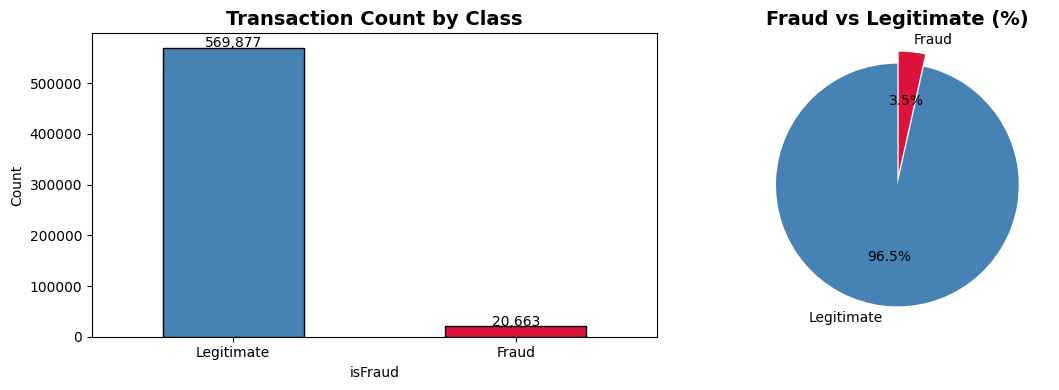

📊 Plot saved: 01_target_distribution.png


In [ ]:

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
fraud_count.plot(kind="bar", ax=axes[0], color=["steelblue", "crimson"],
                 rot=0, edgecolor="black")
axes[0].set_title("Transaction Count by Class", fontsize=14, fontweight="bold")
axes[0].set_xlabel("isFraud")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Legitimate", "Fraud"])
for i, v in enumerate(fraud_count):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

# Pie chart
axes[1].pie(fraud_count, labels=["Legitimate", "Fraud"],
            colors=["steelblue", "crimson"],
            autopct="%1.1f%%", startangle=90,
            explode=(0, 0.1))
axes[1].set_title("Fraud vs Legitimate (%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 01_target_distribution.png")

MISSING VALUES ANALYSIS

Columns with missing values: 414
Columns with >50% missing:   214
Columns with >90% missing:   12

Top 20 most missing columns:
id_24    99.20
id_25    99.13
id_07    99.13
id_08    99.13
id_21    99.13
id_26    99.13
id_27    99.12
id_23    99.12
id_22    99.12
dist2    93.63
D7       93.41
id_18    92.36
D13      89.51
D14      89.47
D12      89.04
id_04    88.77
id_03    88.77
D6       87.61
id_33    87.59
id_09    87.31


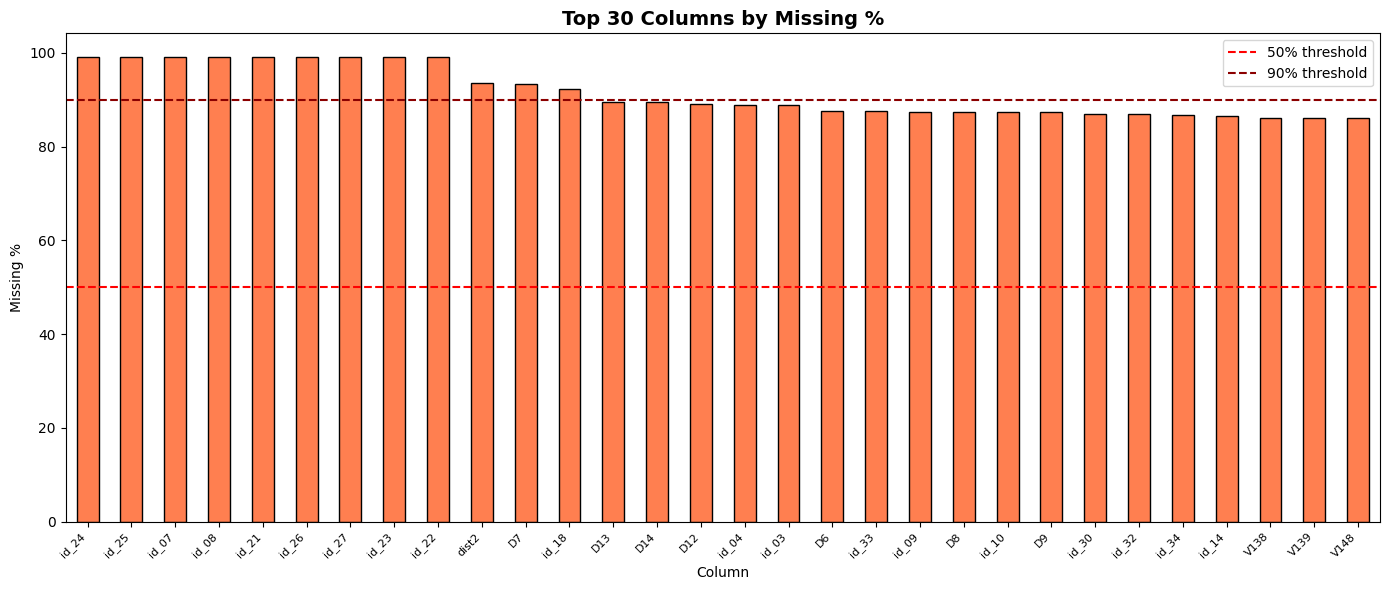

📊 Plot saved: 02_missing_values.png


In [ ]:

# ──────────────────────────────────────────────────────
# CELL 5: MISSING VALUES ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Calculate missing %
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f"\nColumns with missing values: {len(missing)}")
print(f"Columns with >50% missing:   {(missing > 50).sum()}")
print(f"Columns with >90% missing:   {(missing > 90).sum()}")

print("\nTop 20 most missing columns:")
print(missing.head(20).round(2).to_string())

# Plot top 30 missing
plt.figure(figsize=(14, 6))
missing.head(30).plot(kind="bar", color="coral", edgecolor="black")
plt.title("Top 30 Columns by Missing %", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.axhline(y=50, color="red", linestyle="--", label="50% threshold")
plt.axhline(y=90, color="darkred", linestyle="--", label="90% threshold")
plt.legend()
plt.tight_layout()
plt.savefig("02_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 02_missing_values.png")


In [ ]:



# ──────────────────────────────────────────────────────
# CELL 6: TRANSACTION AMOUNT ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

print("\nAmount statistics by fraud label:")
print(train.groupby("isFraud")["TransactionAmt"].describe().round(2))

TRANSACTION AMOUNT ANALYSIS

Amount statistics by fraud label:
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


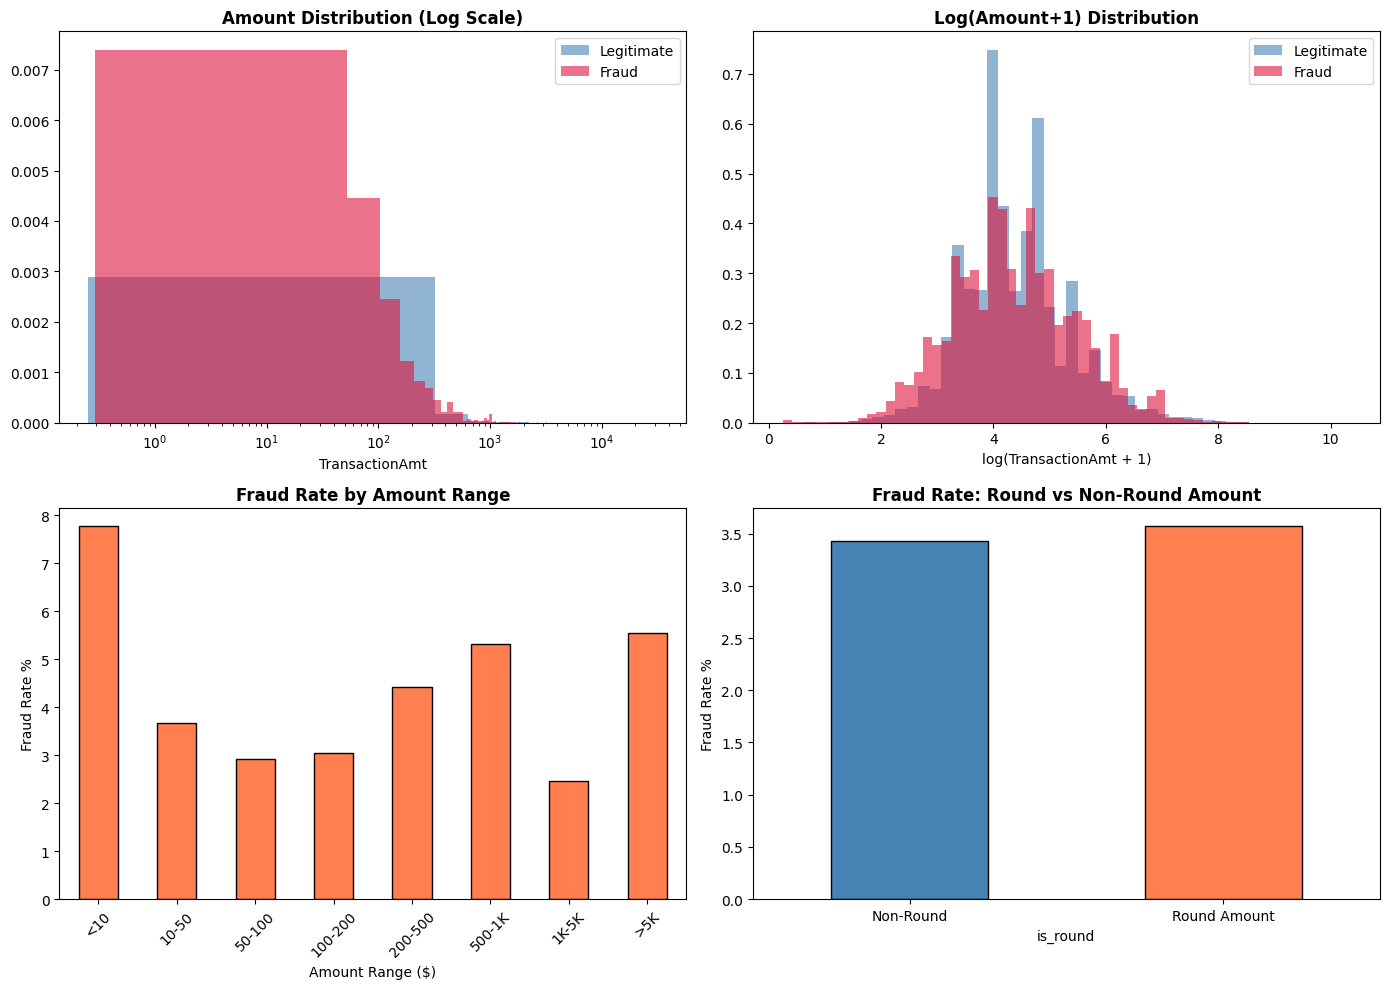

📊 Plot saved: 03_amount_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution (log scale)
axes[0,0].hist(train[train["isFraud"]==0]["TransactionAmt"],
               bins=100, alpha=0.6, label="Legitimate", color="steelblue",
               density=True)
axes[0,0].hist(train[train["isFraud"]==1]["TransactionAmt"],
               bins=100, alpha=0.6, label="Fraud", color="crimson",
               density=True)
axes[0,0].set_xscale("log")
axes[0,0].set_title("Amount Distribution (Log Scale)", fontweight="bold")
axes[0,0].set_xlabel("TransactionAmt")
axes[0,0].legend()



# 2. Log amount distribution
train["log_amt"] = np.log1p(train["TransactionAmt"])
axes[0,1].hist(train[train["isFraud"]==0]["log_amt"],
               bins=50, alpha=0.6, label="Legitimate", color="steelblue",
               density=True)
axes[0,1].hist(train[train["isFraud"]==1]["log_amt"],
               bins=50, alpha=0.6, label="Fraud", color="crimson",
               density=True)
axes[0,1].set_title("Log(Amount+1) Distribution", fontweight="bold")
axes[0,1].set_xlabel("log(TransactionAmt + 1)")
axes[0,1].legend()

# 3. Amount bins fraud rate
bins = [0, 10, 50, 100, 200, 500, 1000, 5000, 100000]
labels = ["<10","10-50","50-100","100-200","200-500","500-1K","1K-5K",">5K"]
train["amt_bin"] = pd.cut(train["TransactionAmt"], bins=bins, labels=labels)
fraud_by_amt = train.groupby("amt_bin")["isFraud"].mean() * 100
fraud_by_amt.plot(kind="bar", ax=axes[1,0], color="coral", edgecolor="black", rot=45)
axes[1,0].set_title("Fraud Rate by Amount Range", fontweight="bold")
axes[1,0].set_ylabel("Fraud Rate %")
axes[1,0].set_xlabel("Amount Range ($)")


# 4. Round amount vs fraud
train["is_round"] = ((train["TransactionAmt"] % 1) == 0).astype(int)
round_fraud = train.groupby("is_round")["isFraud"].mean() * 100
round_fraud.plot(kind="bar", ax=axes[1,1],
                 color=["steelblue","coral"], edgecolor="black", rot=0)
axes[1,1].set_title("Fraud Rate: Round vs Non-Round Amount", fontweight="bold")
axes[1,1].set_ylabel("Fraud Rate %")
axes[1,1].set_xticklabels(["Non-Round", "Round Amount"])

plt.tight_layout()
plt.savefig("03_amount_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 03_amount_analysis.png")



TIME ANALYSIS


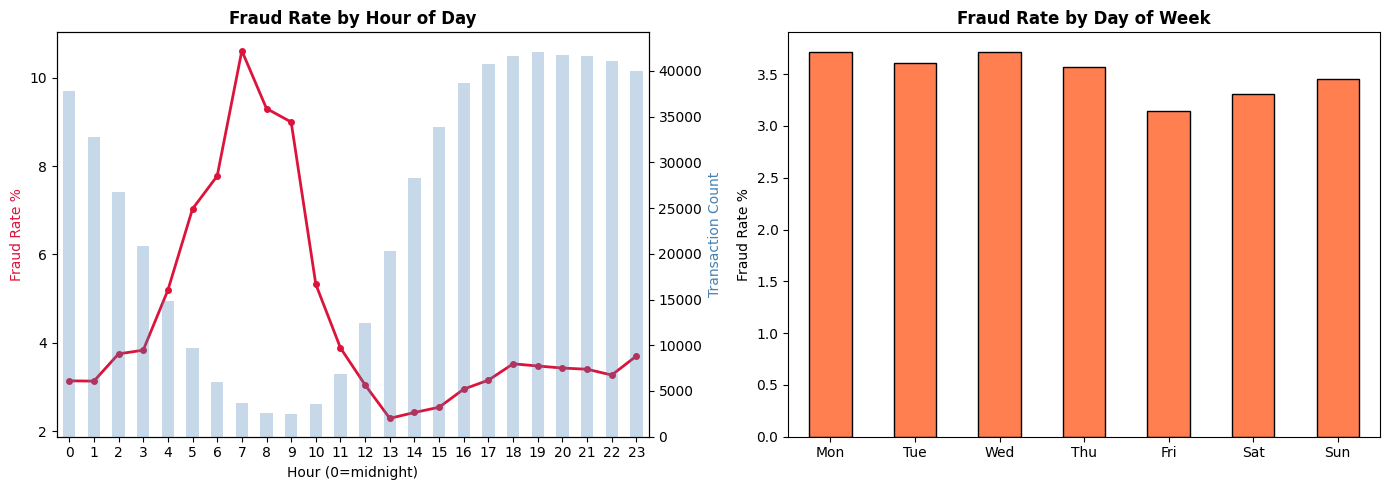

📊 Plot saved: 04_time_analysis.png


In [ ]:

# ──────────────────────────────────────────────────────
# CELL 7: TIME ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("TIME ANALYSIS")
print("=" * 60)

train["hour"]       = (train["TransactionDT"] // 3600) % 24
train["day"]        = train["TransactionDT"] / 86400
train["day_of_week"]= (train["TransactionDT"] // 86400) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by hour
hour_fraud = train.groupby("hour")["isFraud"].mean() * 100
hour_count = train.groupby("hour")["isFraud"].count()

ax2 = axes[0].twinx()
hour_fraud.plot(kind="line", ax=axes[0], color="crimson",
                linewidth=2, marker="o", markersize=4, label="Fraud Rate %")
hour_count.plot(kind="bar", ax=ax2, color="steelblue", alpha=0.3, label="Count")
axes[0].set_title("Fraud Rate by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour (0=midnight)")
axes[0].set_ylabel("Fraud Rate %", color="crimson")
ax2.set_ylabel("Transaction Count", color="steelblue")
axes[0].set_xticks(range(24))

# Fraud rate by day of week
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_fraud = train.groupby("day_of_week")["isFraud"].mean() * 100
dow_fraud.index = day_labels
dow_fraud.plot(kind="bar", ax=axes[1], color="coral",
               edgecolor="black", rot=0)
axes[1].set_title("Fraud Rate by Day of Week", fontweight="bold")
axes[1].set_ylabel("Fraud Rate %")

plt.tight_layout()
plt.savefig("04_time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 04_time_analysis.png")


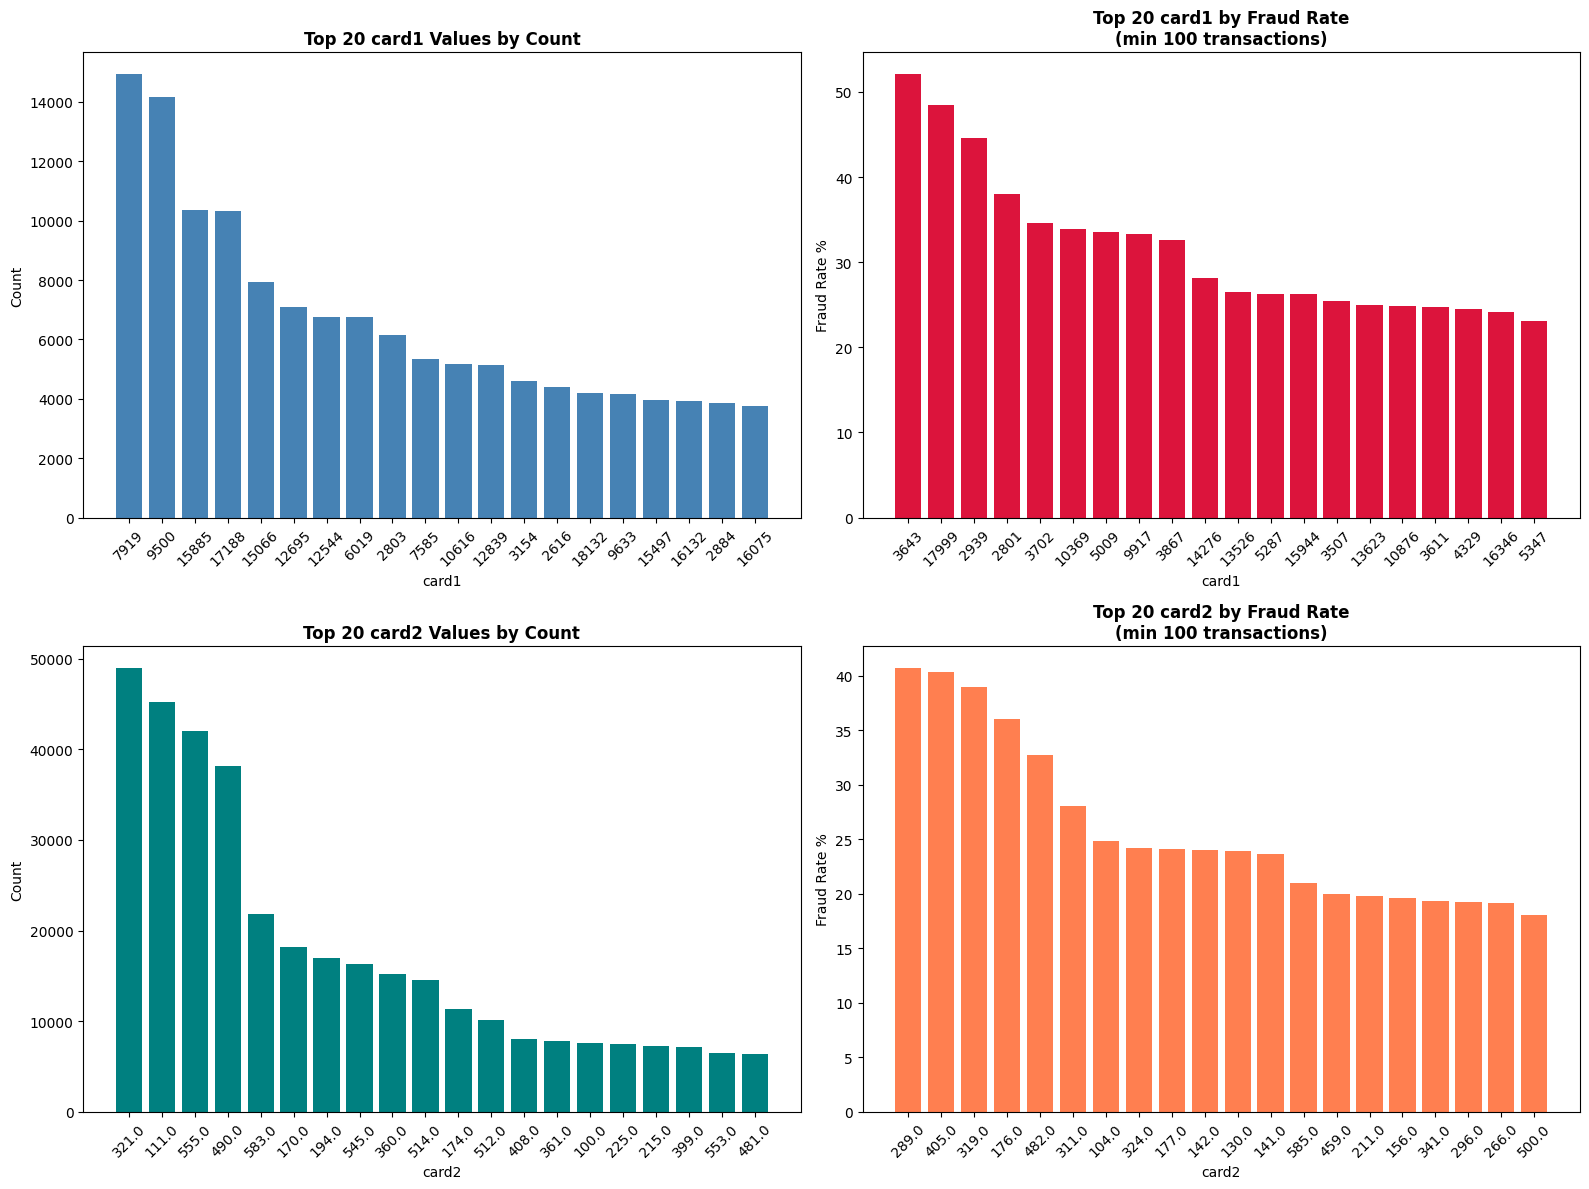

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Top 20 card1 values ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 20 card1 by count
top_card1 = train['card1'].value_counts().head(20)
axes[0,0].bar(top_card1.index.astype(str), top_card1.values, color='steelblue')
axes[0,0].set_title("Top 20 card1 Values by Count", fontweight='bold')
axes[0,0].set_xlabel("card1")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Top 20 card1 by FRAUD RATE (min 100 transactions)
card1_stats = train.groupby('card1').agg(
    count=('isFraud', 'count'),
    fraud_rate=('isFraud', 'mean')
).reset_index()
card1_stats = card1_stats[card1_stats['count'] >= 100]  # min 100 txns
top_fraud_card1 = card1_stats.sort_values('fraud_rate', ascending=False).head(20)

axes[0,1].bar(top_fraud_card1['card1'].astype(str),
              top_fraud_card1['fraud_rate'] * 100, color='crimson')
axes[0,1].set_title("Top 20 card1 by Fraud Rate\n(min 100 transactions)",
                     fontweight='bold')
axes[0,1].set_xlabel("card1")
axes[0,1].set_ylabel("Fraud Rate %")
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Top 20 card2 by count
top_card2 = train['card2'].value_counts().head(20)
axes[1,0].bar(top_card2.index.astype(str), top_card2.values, color='teal')
axes[1,0].set_title("Top 20 card2 Values by Count", fontweight='bold')
axes[1,0].set_xlabel("card2")
axes[1,0].set_ylabel("Count")
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Top 20 card2 by FRAUD RATE
card2_stats = train.groupby('card2').agg(
    count=('isFraud', 'count'),
    fraud_rate=('isFraud', 'mean')
).reset_index()
card2_stats = card2_stats[card2_stats['count'] >= 100]
top_fraud_card2 = card2_stats.sort_values('fraud_rate', ascending=False).head(20)

axes[1,1].bar(top_fraud_card2['card2'].astype(str),
              top_fraud_card2['fraud_rate'] * 100, color='coral')
axes[1,1].set_title("Top 20 card2 by Fraud Rate\n(min 100 transactions)",
                     fontweight='bold')
axes[1,1].set_xlabel("card2")
axes[1,1].set_ylabel("Fraud Rate %")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

CARD & EMAIL ANALYSIS


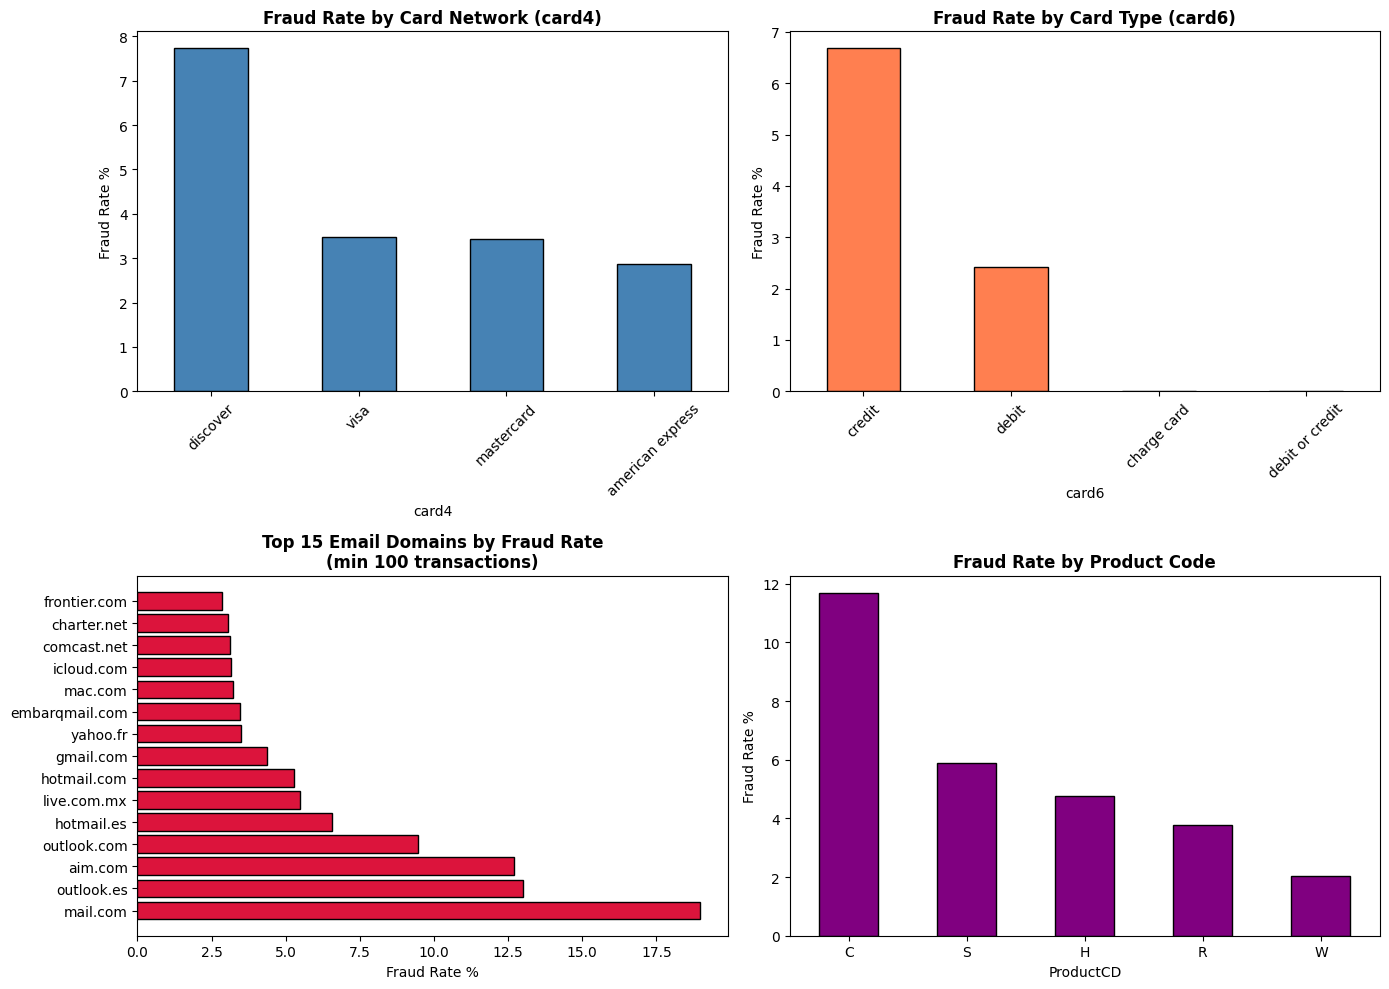

📊 Plot saved: 05_card_email_analysis.png


In [ ]:

# ──────────────────────────────────────────────────────
# CELL 8: CARD & EMAIL ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("CARD & EMAIL ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# card4 (visa/mastercard) fraud rate
card4_fraud = train.groupby("card4")["isFraud"].mean().sort_values(ascending=False) * 100
card4_fraud.plot(kind="bar", ax=axes[0,0], color="steelblue",
                 edgecolor="black", rot=45)
axes[0,0].set_title("Fraud Rate by Card Network (card4)", fontweight="bold")
axes[0,0].set_ylabel("Fraud Rate %")

# card6 (debit/credit) fraud rate
card6_fraud = train.groupby("card6")["isFraud"].mean().sort_values(ascending=False) * 100
card6_fraud.plot(kind="bar", ax=axes[0,1], color="coral",
                 edgecolor="black", rot=45)
axes[0,1].set_title("Fraud Rate by Card Type (card6)", fontweight="bold")
axes[0,1].set_ylabel("Fraud Rate %")

# Top 15 email domains by fraud rate (min 100 transactions)
email_stats = train.groupby("P_emaildomain").agg(
    fraud_rate=("isFraud", "mean"),
    count=("isFraud", "count")
).reset_index()
email_stats = email_stats[email_stats["count"] >= 100].sort_values(
    "fraud_rate", ascending=False
).head(15)
email_stats["fraud_rate"] = email_stats["fraud_rate"] * 100

axes[1,0].barh(email_stats["P_emaildomain"], email_stats["fraud_rate"],
               color="crimson", edgecolor="black")
axes[1,0].set_title("Top 15 Email Domains by Fraud Rate\n(min 100 transactions)",
                     fontweight="bold")
axes[1,0].set_xlabel("Fraud Rate %")

# ProductCD fraud rate
prod_fraud = train.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False) * 100
prod_fraud.plot(kind="bar", ax=axes[1,1], color="purple",
                edgecolor="black", rot=0)
axes[1,1].set_title("Fraud Rate by Product Code", fontweight="bold")
axes[1,1].set_ylabel("Fraud Rate %")

plt.tight_layout()
plt.savefig("05_card_email_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 05_card_email_analysis.png")


C & D COLUMN ANALYSIS


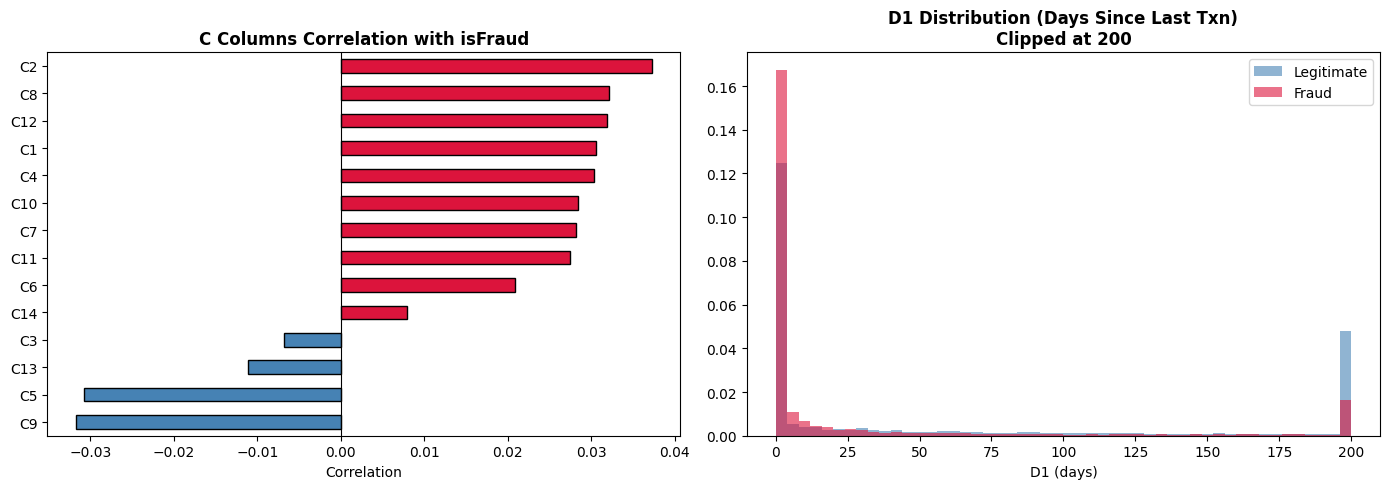


D1 stats by fraud label:
            count   mean     std  min  25%  50%    75%    max
isFraud                                                      
0        568654.0  96.36  158.97  0.0  0.0  4.0  126.0  640.0
1         20617.0  38.71  100.92  0.0  0.0  0.0   14.0  637.0
📊 Plot saved: 06_cd_analysis.png


In [ ]:
# ──────────────────────────────────────────────────────
# CELL 9: C & D COLUMN ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("C & D COLUMN ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C columns correlation with fraud
c_cols = [f"C{i}" for i in range(1, 15)]
c_fraud_corr = train[c_cols + ["isFraud"]].corr()["isFraud"].drop("isFraud").sort_values()
c_fraud_corr.plot(kind="barh", ax=axes[0],
                  color=["crimson" if x > 0 else "steelblue"
                         for x in c_fraud_corr],
                  edgecolor="black")
axes[0].set_title("C Columns Correlation with isFraud", fontweight="bold")
axes[0].set_xlabel("Correlation")
axes[0].axvline(x=0, color="black", linewidth=0.8)

# D1 distribution — fraud vs legit
d1_legit = train[train["isFraud"]==0]["D1"].dropna()
d1_fraud = train[train["isFraud"]==1]["D1"].dropna()

axes[1].hist(d1_legit.clip(0, 200), bins=50, alpha=0.6,
             label="Legitimate", color="steelblue", density=True)
axes[1].hist(d1_fraud.clip(0, 200), bins=50, alpha=0.6,
             label="Fraud", color="crimson", density=True)
axes[1].set_title("D1 Distribution (Days Since Last Txn)\nClipped at 200",
                   fontweight="bold")
axes[1].set_xlabel("D1 (days)")
axes[1].legend()

plt.tight_layout()
plt.savefig("06_cd_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Print D1 stats
print("\nD1 stats by fraud label:")
print(train.groupby("isFraud")["D1"].describe().round(2))
print("📊 Plot saved: 06_cd_analysis.png")

TRANSACTION AMOUNT ANALYSIS

Amount statistics by fraud label:
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


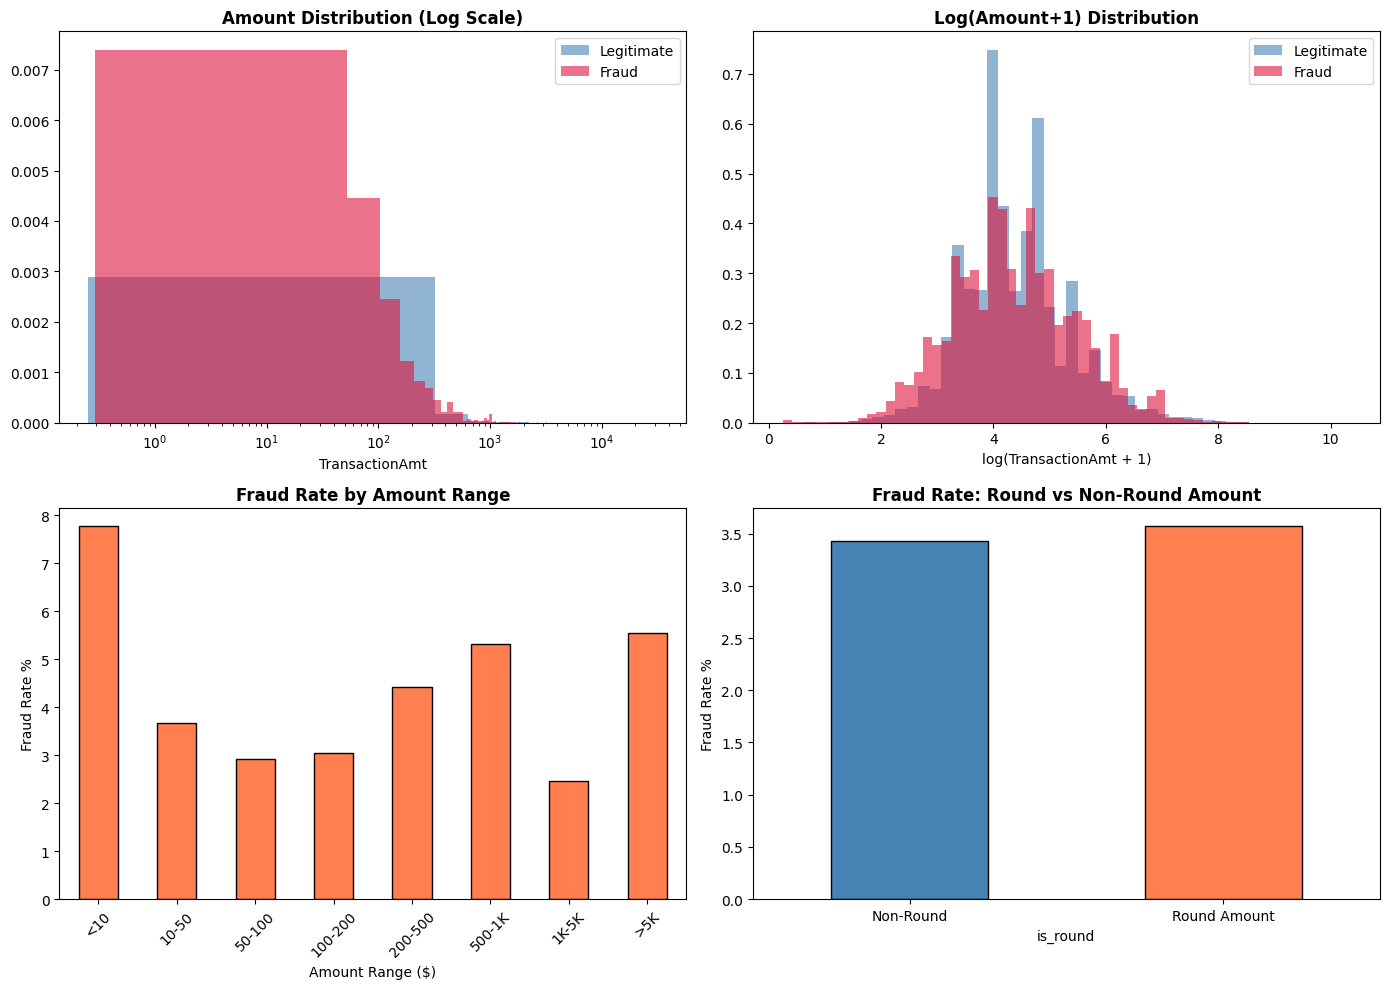

📊 Plot saved: 03_amount_analysis.png
TIME ANALYSIS


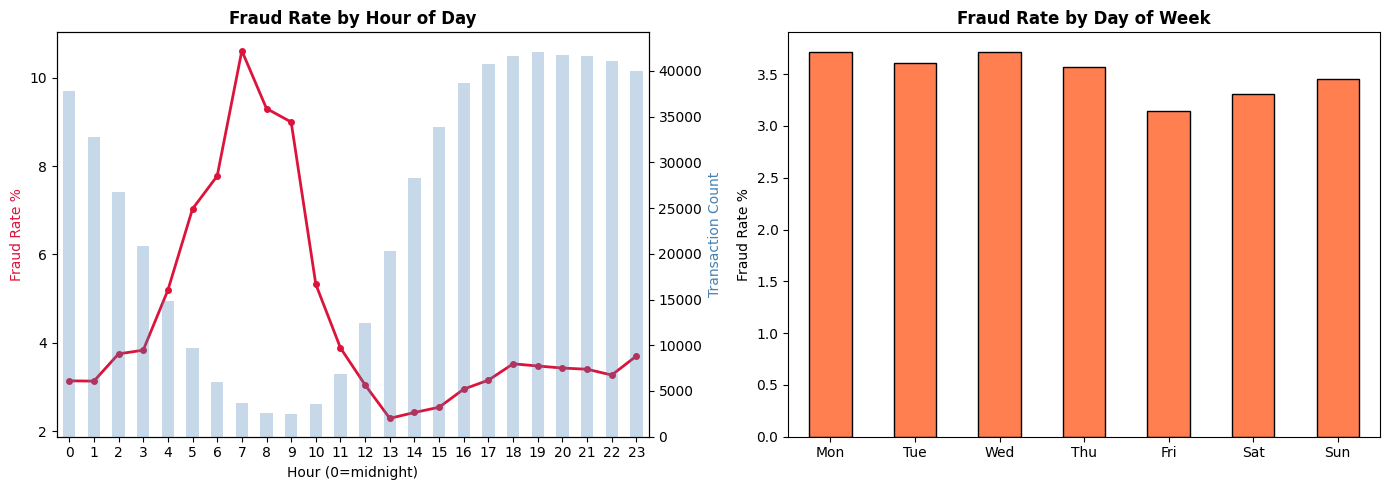

📊 Plot saved: 04_time_analysis.png
CARD & EMAIL ANALYSIS


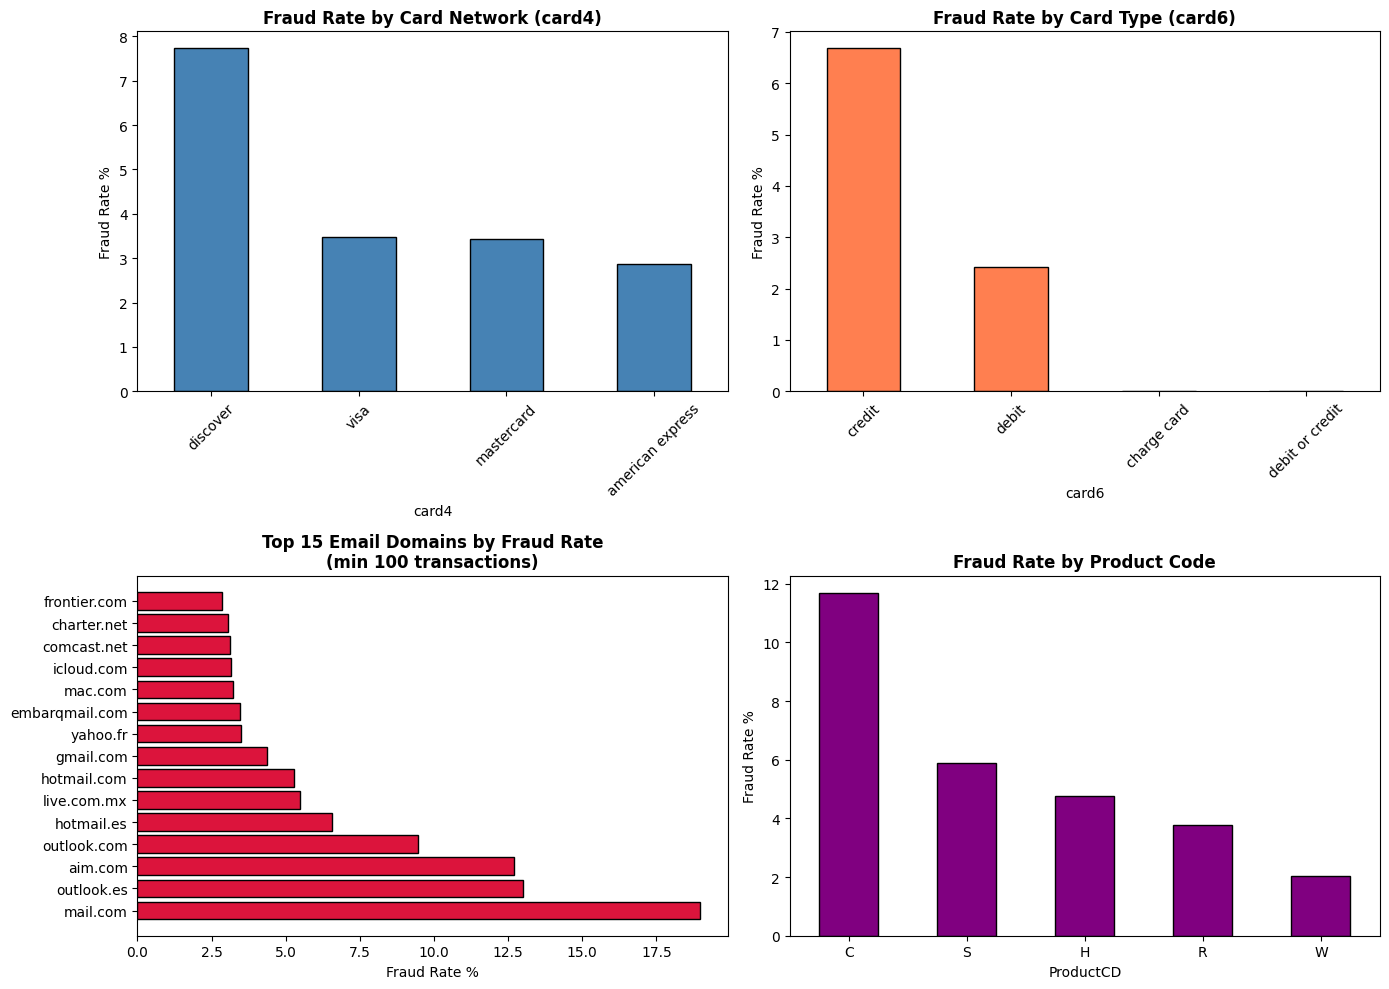

📊 Plot saved: 05_card_email_analysis.png
C & D COLUMN ANALYSIS


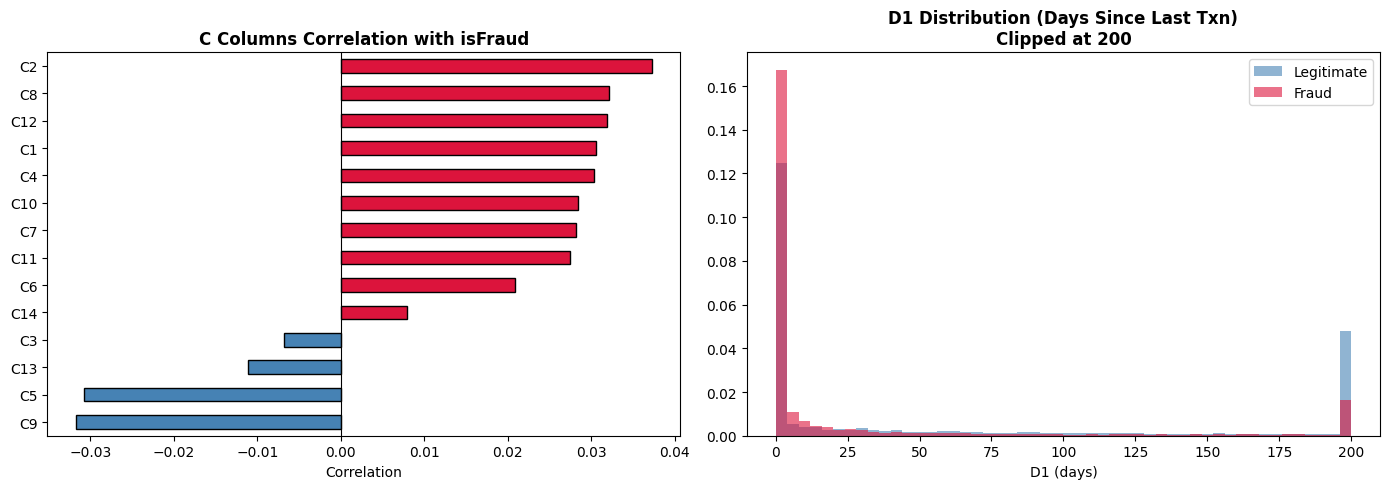


D1 stats by fraud label:
            count   mean     std  min  25%  50%    75%    max
isFraud                                                      
0        568654.0  96.36  158.97  0.0  0.0  4.0  126.0  640.0
1         20617.0  38.71  100.92  0.0  0.0  0.0   14.0  637.0
📊 Plot saved: 06_cd_analysis.png
M COLUMN (MATCH FEATURES) ANALYSIS


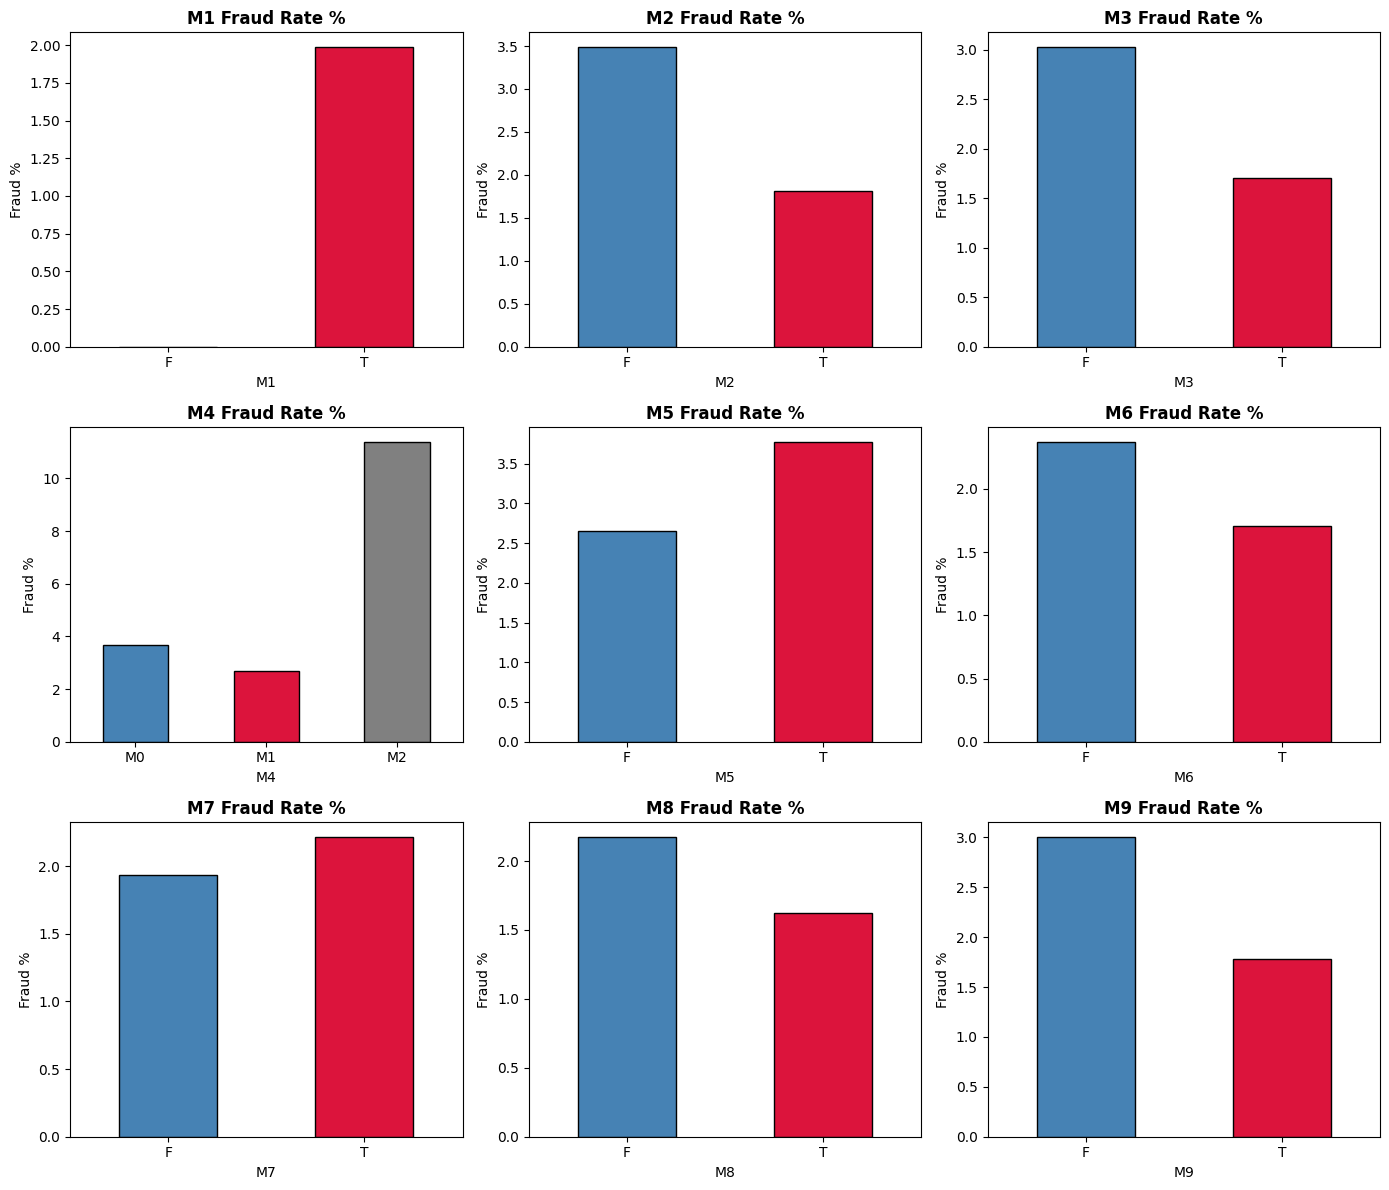

📊 Plot saved: 07_m_columns.png
FEATURE ENGINEERING
Engineering train features...


In [ ]:




# ──────────────────────────────────────────────────────
# CELL 6: TRANSACTION AMOUNT ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

print("\nAmount statistics by fraud label:")
print(train.groupby("isFraud")["TransactionAmt"].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution (log scale)
axes[0,0].hist(train[train["isFraud"]==0]["TransactionAmt"],
               bins=100, alpha=0.6, label="Legitimate", color="steelblue",
               density=True)
axes[0,0].hist(train[train["isFraud"]==1]["TransactionAmt"],
               bins=100, alpha=0.6, label="Fraud", color="crimson",
               density=True)
axes[0,0].set_xscale("log")
axes[0,0].set_title("Amount Distribution (Log Scale)", fontweight="bold")
axes[0,0].set_xlabel("TransactionAmt")
axes[0,0].legend()

# 2. Log amount distribution
train["log_amt"] = np.log1p(train["TransactionAmt"])
axes[0,1].hist(train[train["isFraud"]==0]["log_amt"],
               bins=50, alpha=0.6, label="Legitimate", color="steelblue",
               density=True)
axes[0,1].hist(train[train["isFraud"]==1]["log_amt"],
               bins=50, alpha=0.6, label="Fraud", color="crimson",
               density=True)
axes[0,1].set_title("Log(Amount+1) Distribution", fontweight="bold")
axes[0,1].set_xlabel("log(TransactionAmt + 1)")
axes[0,1].legend()

# 3. Amount bins fraud rate
bins = [0, 10, 50, 100, 200, 500, 1000, 5000, 100000]
labels = ["<10","10-50","50-100","100-200","200-500","500-1K","1K-5K",">5K"]
train["amt_bin"] = pd.cut(train["TransactionAmt"], bins=bins, labels=labels)
fraud_by_amt = train.groupby("amt_bin")["isFraud"].mean() * 100
fraud_by_amt.plot(kind="bar", ax=axes[1,0], color="coral", edgecolor="black", rot=45)
axes[1,0].set_title("Fraud Rate by Amount Range", fontweight="bold")
axes[1,0].set_ylabel("Fraud Rate %")
axes[1,0].set_xlabel("Amount Range ($)")

# 4. Round amount vs fraud
train["is_round"] = ((train["TransactionAmt"] % 1) == 0).astype(int)
round_fraud = train.groupby("is_round")["isFraud"].mean() * 100
round_fraud.plot(kind="bar", ax=axes[1,1],
                 color=["steelblue","coral"], edgecolor="black", rot=0)
axes[1,1].set_title("Fraud Rate: Round vs Non-Round Amount", fontweight="bold")
axes[1,1].set_ylabel("Fraud Rate %")
axes[1,1].set_xticklabels(["Non-Round", "Round Amount"])

plt.tight_layout()
plt.savefig("03_amount_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 03_amount_analysis.png")


# ──────────────────────────────────────────────────────
# CELL 7: TIME ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("TIME ANALYSIS")
print("=" * 60)

train["hour"]       = (train["TransactionDT"] // 3600) % 24
train["day"]        = train["TransactionDT"] / 86400
train["day_of_week"]= (train["TransactionDT"] // 86400) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by hour
hour_fraud = train.groupby("hour")["isFraud"].mean() * 100
hour_count = train.groupby("hour")["isFraud"].count()

ax2 = axes[0].twinx()
hour_fraud.plot(kind="line", ax=axes[0], color="crimson",
                linewidth=2, marker="o", markersize=4, label="Fraud Rate %")
hour_count.plot(kind="bar", ax=ax2, color="steelblue", alpha=0.3, label="Count")
axes[0].set_title("Fraud Rate by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour (0=midnight)")
axes[0].set_ylabel("Fraud Rate %", color="crimson")
ax2.set_ylabel("Transaction Count", color="steelblue")
axes[0].set_xticks(range(24))

# Fraud rate by day of week
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_fraud = train.groupby("day_of_week")["isFraud"].mean() * 100
dow_fraud.index = day_labels
dow_fraud.plot(kind="bar", ax=axes[1], color="coral",
               edgecolor="black", rot=0)
axes[1].set_title("Fraud Rate by Day of Week", fontweight="bold")
axes[1].set_ylabel("Fraud Rate %")

plt.tight_layout()
plt.savefig("04_time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 04_time_analysis.png")


# ──────────────────────────────────────────────────────
# CELL 8: CARD & EMAIL ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("CARD & EMAIL ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# card4 (visa/mastercard) fraud rate
card4_fraud = train.groupby("card4")["isFraud"].mean().sort_values(ascending=False) * 100
card4_fraud.plot(kind="bar", ax=axes[0,0], color="steelblue",
                 edgecolor="black", rot=45)
axes[0,0].set_title("Fraud Rate by Card Network (card4)", fontweight="bold")
axes[0,0].set_ylabel("Fraud Rate %")

# card6 (debit/credit) fraud rate
card6_fraud = train.groupby("card6")["isFraud"].mean().sort_values(ascending=False) * 100
card6_fraud.plot(kind="bar", ax=axes[0,1], color="coral",
                 edgecolor="black", rot=45)
axes[0,1].set_title("Fraud Rate by Card Type (card6)", fontweight="bold")
axes[0,1].set_ylabel("Fraud Rate %")

# Top 15 email domains by fraud rate (min 100 transactions)
email_stats = train.groupby("P_emaildomain").agg(
    fraud_rate=("isFraud", "mean"),
    count=("isFraud", "count")
).reset_index()
email_stats = email_stats[email_stats["count"] >= 100].sort_values(
    "fraud_rate", ascending=False
).head(15)
email_stats["fraud_rate"] = email_stats["fraud_rate"] * 100

axes[1,0].barh(email_stats["P_emaildomain"], email_stats["fraud_rate"],
               color="crimson", edgecolor="black")
axes[1,0].set_title("Top 15 Email Domains by Fraud Rate\n(min 100 transactions)",
                     fontweight="bold")
axes[1,0].set_xlabel("Fraud Rate %")

# ProductCD fraud rate
prod_fraud = train.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False) * 100
prod_fraud.plot(kind="bar", ax=axes[1,1], color="purple",
                edgecolor="black", rot=0)
axes[1,1].set_title("Fraud Rate by Product Code", fontweight="bold")
axes[1,1].set_ylabel("Fraud Rate %")

plt.tight_layout()
plt.savefig("05_card_email_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 05_card_email_analysis.png")


# ──────────────────────────────────────────────────────
# CELL 9: C & D COLUMN ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("C & D COLUMN ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C columns correlation with fraud
c_cols = [f"C{i}" for i in range(1, 15)]
c_fraud_corr = train[c_cols + ["isFraud"]].corr()["isFraud"].drop("isFraud").sort_values()
c_fraud_corr.plot(kind="barh", ax=axes[0],
                  color=["crimson" if x > 0 else "steelblue"
                         for x in c_fraud_corr],
                  edgecolor="black")
axes[0].set_title("C Columns Correlation with isFraud", fontweight="bold")
axes[0].set_xlabel("Correlation")
axes[0].axvline(x=0, color="black", linewidth=0.8)

# D1 distribution — fraud vs legit
d1_legit = train[train["isFraud"]==0]["D1"].dropna()
d1_fraud = train[train["isFraud"]==1]["D1"].dropna()

axes[1].hist(d1_legit.clip(0, 200), bins=50, alpha=0.6,
             label="Legitimate", color="steelblue", density=True)
axes[1].hist(d1_fraud.clip(0, 200), bins=50, alpha=0.6,
             label="Fraud", color="crimson", density=True)
axes[1].set_title("D1 Distribution (Days Since Last Txn)\nClipped at 200",
                   fontweight="bold")
axes[1].set_xlabel("D1 (days)")
axes[1].legend()

plt.tight_layout()
plt.savefig("06_cd_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Print D1 stats
print("\nD1 stats by fraud label:")
print(train.groupby("isFraud")["D1"].describe().round(2))
print("📊 Plot saved: 06_cd_analysis.png")


# ──────────────────────────────────────────────────────
# CELL 10: M COLUMN ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("M COLUMN (MATCH FEATURES) ANALYSIS")
print("=" * 60)

m_cols = [f"M{i}" for i in range(1, 10)]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(m_cols):
    if col in train.columns:
        m_fraud = train.groupby(col)["isFraud"].mean() * 100
        m_fraud.plot(kind="bar", ax=axes[i],
                    color=["steelblue","crimson","gray"][:len(m_fraud)],
                    edgecolor="black", rot=0)
        axes[i].set_title(f"{col} Fraud Rate %", fontweight="bold")
        axes[i].set_ylabel("Fraud %")

plt.tight_layout()
plt.savefig("07_m_columns.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 07_m_columns.png")


# ──────────────────────────────────────────────────────
# CELL 11: FEATURE ENGINEERING
# ──────────────────────────────────────────────────────
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

def engineer_features(df):
    df = df.copy()

    # ── Level 1: Basic ──────────────────────────────
    # Amount features
    df["amt_log"]     = np.log1p(df["TransactionAmt"])
    df["amt_decimal"] = df["TransactionAmt"] - df["TransactionAmt"].astype(int)
    df["is_round"]    = (df["amt_decimal"] == 0).astype(int)

    # Time features
    df["hour"]        = (df["TransactionDT"] // 3600) % 24
    df["day"]         = df["TransactionDT"] / 86400
    df["day_of_week"] = (df["TransactionDT"] // 86400) % 7
    df["is_night"]    = df["hour"].apply(lambda x: 1 if (x >= 23 or x <= 5) else 0)
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

    # Email features
    free_emails = ["gmail.com","yahoo.com","hotmail.com",
                   "outlook.com","aol.com","live.com"]
    df["is_free_email"]  = df["P_emaildomain"].isin(free_emails).astype(int)
    df["email_match"]    = (df["P_emaildomain"] == df["R_emaildomain"]).astype(int)
    df["email_p_missing"]= df["P_emaildomain"].isna().astype(int)
    df["email_r_missing"]= df["R_emaildomain"].isna().astype(int)

    # Null count
    df["null_count"] = df.isnull().sum(axis=1)

    # ── Level 2: GroupBy aggregations ───────────────
    print("  Creating GroupBy features...")
    for col in ["card1","card2","addr1","P_emaildomain"]:
        df[f"{col}_amt_mean"]  = df.groupby(col)["TransactionAmt"].transform("mean")
        df[f"{col}_amt_std"]   = df.groupby(col)["TransactionAmt"].transform("std").fillna(0)
        df[f"{col}_count"]     = df.groupby(col)["TransactionAmt"].transform("count")
        df[f"{col}_amt_ratio"] = df["TransactionAmt"] / (df[f"{col}_amt_mean"] + 1)

    # ── Level 2: UID features ────────────────────────
    print("  Creating UID features...")
    df["D1n"] = df["day"] - df["D1"]
    df["uid"] = (df["card1"].astype(str) + "_" +
                 df["addr1"].astype(str) + "_" +
                 np.floor(df["D1n"].fillna(-1)).astype(str))

    df["uid_amt_mean"]   = df.groupby("uid")["TransactionAmt"].transform("mean")
    df["uid_amt_std"]    = df.groupby("uid")["TransactionAmt"].transform("std").fillna(0)
    df["uid_count"]      = df.groupby("uid")["TransactionAmt"].transform("count")
    df["uid_amt_ratio"]  = df["TransactionAmt"] / (df["uid_amt_mean"] + 1)
    df["uid_amt_nunique"]= df.groupby("uid")["TransactionAmt"].transform("nunique")
    df.drop("uid", axis=1, inplace=True)

    # ── Level 2: Frequency encoding ─────────────────
    print("  Creating Frequency features...")
    cat_cols = ["card1","card2","card3","card5",
                "addr1","addr2","P_emaildomain",
                "R_emaildomain","ProductCD","DeviceType","DeviceInfo"]
    for col in cat_cols:
        if col in df.columns:
            freq = df[col].value_counts(normalize=True)
            df[f"{col}_freq"] = df[col].map(freq).fillna(0)

    # ── Level 2: D column features ───────────────────
    print("  Creating D column features...")
    df["is_rapid_txn"] = (df["D1"] < 1).astype(int)
    df["is_dormant"]   = (df["D1"] > 180).astype(int)
    df["D1_missing"]   = df["D1"].isna().astype(int)

    for d_col in ["D1","D2","D3","D4","D5"]:
        if d_col in df.columns:
            df[f"{d_col}_norm"]    = df[d_col] / (df["day"] + 1)
            df[f"{d_col}_missing"] = df[d_col].isna().astype(int)

    # ── M columns: count mismatches ──────────────────
    m_cols = [f"M{i}" for i in range(1,10)]
    m_cols_present = [c for c in m_cols if c in df.columns]
    df["m_false_count"] = (df[m_cols_present] == "F").sum(axis=1)
    df["m_true_count"]  = (df[m_cols_present] == "T").sum(axis=1)

    print(f"  ✅ Feature engineering done! Shape: {df.shape}")
    return df

print("Engineering train features...")
train = engineer_features(train)
print("Engineering test features...")
test  = engineer_features(test)

print(f"\n✅ Train shape after FE: {train.shape}")
print(f"✅ Test shape after FE:  {test.shape}")


# ──────────────────────────────────────────────────────
# CELL 12: PREPARE FOR ML
# ──────────────────────────────────────────────────────
print("=" * 60)
print("PREPARING DATA FOR ML")
print("=" * 60)

# Drop useless columns
drop_cols = ["TransactionID", "TransactionDT", "isFraud",
             "log_amt", "day", "D1n",     # already used in features
             "amt_bin", "is_round"]        # created during EDA only

# Get feature columns
feature_cols = [c for c in train.columns
                if c not in drop_cols + ["isFraud"]]

# Label encode categorical columns
print("Label encoding categorical columns...")
cat_cols = train[feature_cols].select_dtypes(include=["object"]).columns.tolist()
print(f"  Categorical cols to encode: {len(cat_cols)}")
print(f"  {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    # Combine train+test to handle unseen values
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

# Final X and y
X = train[feature_cols]
y = train["isFraud"]
X_test = test[feature_cols]

# Fill remaining NaN with -999 (XGBoost handles this)
X      = X.fillna(-999)
X_test = X_test.fillna(-999)

print(f"\n✅ X shape:      {X.shape}")
print(f"✅ y shape:      {y.shape}")
print(f"✅ X_test shape: {X_test.shape}")
print(f"\nFraud rate: {y.mean()*100:.2f}%")


# ──────────────────────────────────────────────────────
# CELL 13: TRAIN XGBOOST WITH CROSS-VALIDATION
# ──────────────────────────────────────────────────────
print("=" * 60)
print("TRAINING XGBOOST MODEL")
print("=" * 60)

# XGBoost parameters
xgb_params = {
    "n_estimators":     500,
    "max_depth":        6,
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 100,
    "scale_pos_weight": int(y.value_counts()[0] / y.value_counts()[1]),
                        # handles class imbalance automatically
    "tree_method":      "hist",  # fast training
    "random_state":     42,
    "eval_metric":      "auc",
    "early_stopping_rounds": 50,
    "verbosity":        0
}

print(f"scale_pos_weight: {xgb_params['scale_pos_weight']}")
print("  (balances fraud vs legitimate classes)")

# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds   = np.zeros(len(X))          # out-of-fold predictions
test_preds  = np.zeros(len(X_test))     # test predictions
fold_aucs   = []
feature_importance_df = pd.DataFrame()

print("\nStarting 5-fold cross validation...")
print("-" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = X.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    # Train model
    model = XGBClassifier(**xgb_params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        verbose=False
    )

    # Predict
    val_pred  = model.predict_proba(X_val_fold)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    # Store predictions
    oof_preds[val_idx] = val_pred
    test_preds += test_pred / 5  # average across folds

    # AUC
    fold_auc = roc_auc_score(y_val_fold, val_pred)
    fold_aucs.append(fold_auc)
    print(f"  Fold {fold} AUC: {fold_auc:.5f}")

    # Feature importance
    fi = pd.DataFrame({
        "feature":    feature_cols,
        "importance": model.feature_importances_,
        "fold":       fold
    })
    feature_importance_df = pd.concat([feature_importance_df, fi])

    gc.collect()

# Overall OOF AUC
oof_auc = roc_auc_score(y, oof_preds)
print("-" * 50)
print(f"\nFold AUCs:     {[round(a,5) for a in fold_aucs]}")
print(f"Mean Fold AUC: {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}")
print(f"OOF AUC:       {oof_auc:.5f}")


# ──────────────────────────────────────────────────────
# CELL 14: FEATURE IMPORTANCE
# ──────────────────────────────────────────────────────
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Average importance across folds
mean_importance = (feature_importance_df
                   .groupby("feature")["importance"]
                   .mean()
                   .sort_values(ascending=False))

print("\nTop 30 most important features:")
print(mean_importance.head(30).round(4).to_string())

# Plot
plt.figure(figsize=(12, 10))
mean_importance.head(30).sort_values().plot(
    kind="barh", color="steelblue", edgecolor="black"
)
plt.title("Top 30 Feature Importances (Mean across 5 folds)",
          fontsize=14, fontweight="bold")
plt.xlabel("Mean Importance Score")
plt.tight_layout()
plt.savefig("08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved: 08_feature_importance.png")


# ──────────────────────────────────────────────────────
# CELL 15: SCORE DISTRIBUTION ANALYSIS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("SCORE DISTRIBUTION ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OOF score distribution
axes[0].hist(oof_preds[y==0], bins=100, alpha=0.6,
             label="Legitimate", color="steelblue", density=True)
axes[0].hist(oof_preds[y==1], bins=100, alpha=0.6,
             label="Fraud", color="crimson", density=True)
axes[0].set_title("Predicted Fraud Probability Distribution",
                   fontweight="bold")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].set_xlim(0, 1)

# Threshold analysis
thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    preds_binary = (oof_preds >= thresh).astype(int)
    tp = ((preds_binary == 1) & (y == 1)).sum()
    fp = ((preds_binary == 1) & (y == 0)).sum()
    fn = ((preds_binary == 0) & (y == 1)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0)

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)

axes[1].plot(thresholds, precisions, "b-o", markersize=4, label="Precision")
axes[1].plot(thresholds, recalls,    "r-o", markersize=4, label="Recall")
axes[1].plot(thresholds, f1s,        "g-o", markersize=4, label="F1")
axes[1].axvline(x=thresholds[np.argmax(f1s)], color="gray",
                linestyle="--", label=f"Best threshold={thresholds[np.argmax(f1s)]:.2f}")
axes[1].set_title("Precision / Recall / F1 vs Threshold",
                   fontweight="bold")
axes[1].set_xlabel("Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("09_score_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

best_thresh = thresholds[np.argmax(f1s)]
print(f"\nBest threshold for F1: {best_thresh:.2f}")
print(f"At this threshold:")
preds_best = (oof_preds >= best_thresh).astype(int)
print(classification_report(y, preds_best,
      target_names=["Legitimate","Fraud"]))
print("📊 Plot saved: 09_score_analysis.png")


# ──────────────────────────────────────────────────────
# CELL 16: CREATE SUBMISSION FILE
# ──────────────────────────────────────────────────────
print("=" * 60)
print("CREATING SUBMISSION FILE")
print("=" * 60)

submission = pd.DataFrame({
    "TransactionID": test_transaction["TransactionID"],
    "isFraud":       test_preds
})

submission.to_csv("submission.csv", index=False)

print(f"✅ Submission file created!")
print(f"   Rows: {len(submission):,}")
print(f"\nPrediction statistics:")
print(f"  Mean predicted fraud prob: {test_preds.mean():.4f}")
print(f"  % predicted as fraud (>0.5): {(test_preds > 0.5).mean()*100:.2f}%")
print(f"\nFirst 5 rows of submission:")
print(submission.head())

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"✅ Rows processed:      {len(train):,}")
print(f"✅ Features engineered: {len(feature_cols)}")
print(f"✅ CV Folds:            5")
print(f"✅ OOF AUC:             {oof_auc:.5f}")
print(f"✅ Mean Fold AUC:       {np.mean(fold_aucs):.5f}")
print(f"✅ Submission:          submission.csv")
